In [8]:
import datahandler
import matplotlib.pyplot as plt

In [2]:
inference = "/scratch/project_465001235/vandenbl/anemoi/experiments/inference/lam_real_test/fc_init_20071105_00.nc"
datasets = "/scratch/project_465001235/datasets/lam-rr-an-oper-0001-mars-5p5km-1984-2020-3h-rmi-v1.zarr"

In [3]:
fcst = datahandler.anemoi_inference(
    inference,
    dataset_attrs={"thinning":4}
)
obs = datahandler.anemoi_datasets(
    datasets,
    thinning=4
)

/pfs/lustrep4/scratch/project_465001235/vanginde/rmai-verification/datahandler.py:117: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds = ds.swap_dims({"time":"valid_time"})


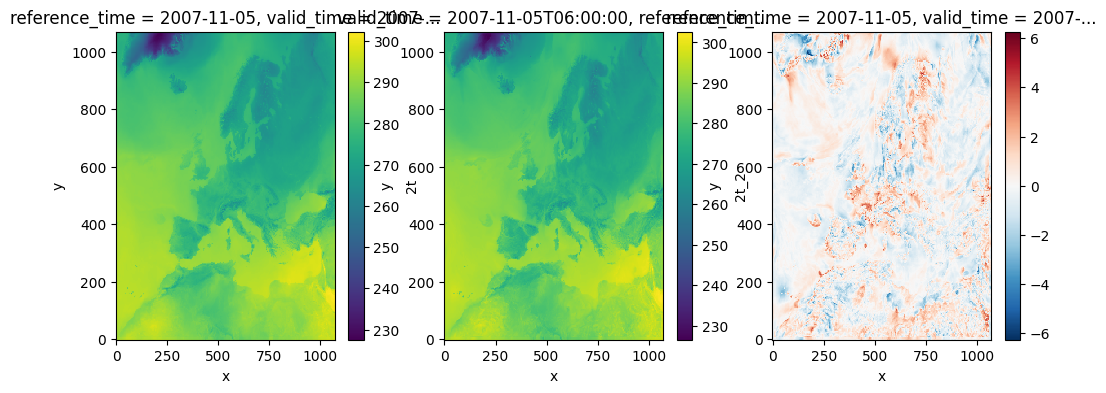

In [9]:
i_reference_time=0
i_lead_time=0


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
fcst["2t"].isel(
    reference_time=i_reference_time,
    lead_time=i_lead_time
).plot(x="x",y="y",ax=axes[0])

obs["2t_2"].sel(
    valid_time=fcst.valid_time.isel(
        reference_time=i_reference_time,
        lead_time=i_lead_time
    )
).plot(x="x",y="y",ax=axes[1])

(fcst["2t"].isel(
    reference_time=i_reference_time,
    lead_time=i_lead_time
) - obs["2t_2"].sel(
    valid_time=fcst.valid_time.isel(
        reference_time=i_reference_time,
        lead_time=i_lead_time
    )
)).plot(x="x",y="y",ax=axes[2])
